# 02 - Generalizability

## Imports

In [155]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
from scipy.interpolate import interp1d

# Make sure we get outputs from a probabilitistic model each time (for reproducibility) 
np.random.seed(1515)

## Prediction with Good vs. Bad Data

Let's go back to our previous example with the test scores. We established that while we have seen the "true" relationship between hours spent studying and exam scores for AP Calculus AB, we don't actually observe that in real life. We have a "good" dataset in Period 3 scores because there is less noise, whereas Period 1 has more noise and therefore demonstrates a different relationship - but how much worse is this? 

Let's create a model for each data, and evaluate its performance. 

### Model for Good Data

Let's look at the model we used for our good data:

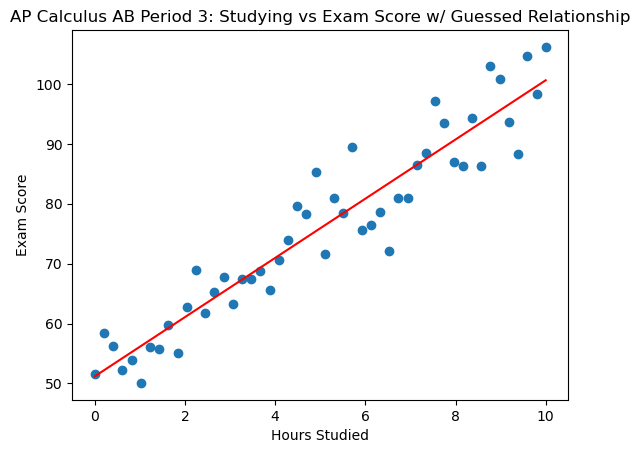

In [137]:
# copy and pasting code over from other notebook (except for using the line fitting 

# Hours studied
hours = np.linspace(0, 10, 50)

# Exam score with moderate noise
scores_good = 5 * hours + 50 + np.random.normal(0, 5, size=len(hours))

coeffs_good = np.polyfit(hours, scores_good, deg=1) # fit a polynomial to your data 
poly_good = np.poly1d(coeffs_good)

y_fit_good = poly_good(hours)

plt.figure()
plt.scatter(hours, scores_good)
plt.plot(hours, y_fit_good, color = 'red')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 3: Studying vs Exam Score w/ Guessed Relationship")
plt.show()

Note that instead of plugging in the values to the linear equation, we just used `np.poly1d` to create the function for us.

Our guess for a line seems like it models the data pretty well! We will get to using math to show that it does do a good job of fitting, but for now we can just use our visual to see that it does a good job on the data. So, we move onto the bad model.

### Model for Bad Data

Let's look at the line we picked last time for our bad data: 

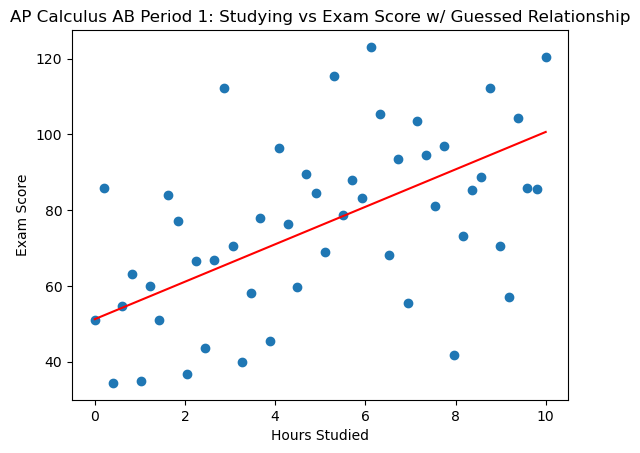

In [195]:
scores_bad = 5 * hours + 50 + np.random.normal(0, 20, size=len(hours))

coeffs_bad = np.polyfit(hours, scores_good, deg=1) # fit a polynomial to your data 
poly_bad = np.poly1d(coeffs_bad)

y_fit_bad= poly_bad(hours)

plt.figure()
plt.scatter(hours, scores_bad)
plt.plot(hours, y_fit_bad, color = 'red')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 1: Studying vs Exam Score w/ Guessed Relationship")
plt.show()

As we talked about before, this line doesn't visually look like it is a good fit for our data! While we do know that this data is noisy, in real life, we wouldn't have this information. So, we have to make a good guess as to what the relationship in this data looks like. Let's go to the other extreme: what if our model fits every single point? 

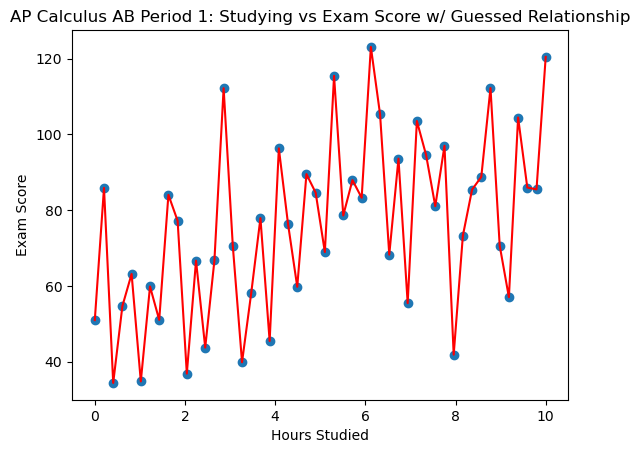

In [198]:
poly_bad = interp1d(hours, scores_bad, kind='cubic') # this function fits every point perfectly 
y_fit_bad = poly_bad(hours)

plt.figure()
plt.scatter(hours, scores_bad)
plt.plot(hours, y_fit_bad, color = 'red')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 1: Studying vs Exam Score w/ Guessed Relationship")
plt.show()

Now, our model looks like it fits our data. Let's see how it performs compared to the "good" model.

### Model Performance Comparison: How does it Perform on its Own Data?

We're gonna introduce probably the most popular performance metric for measuring error, or how wrong our model is. First, before we get to evaluating our models on unseen data, let's quantify how they do on their own data. 

The metric we will be using is something called Root Mean Squared Error:

$RMSE = \sqrt{{\frac{1}{n}\sum^n_{i=1}(\hat{y_i} - y_i)^2}}$

Again, don't stress about every part of this formula (though I do encourage you to think about what it means). The important thing to remember is that this basically measures how far off the average point our model has is from the true point location in the data. 

We will calculate the RMSE for each of our models below: 

In [223]:
# calculate RMSE 

rmse_good = root_mean_squared_error(scores_good, y_fit_good)
rmse_bad = root_mean_squared_error(scores_bad, y_fit_bad)

print(f'RMSE for Good Model on Own Data: {round(rmse_good, 2)}')
print(f'RMSE for Bad Model on Own Data: {round(rmse_bad, 2)}')

RMSE for Good Model on Own Data: 4.87
RMSE for Bad Model on Own Data: 0.0


This seems a little counterintuitive, right? Our "bad" data gave us a "bad" model that has no errors, while our "good" one is worse? 

Well, this leads us to arguably the most important idea behind building good models: **Generalizability**

### Generalizability

Remember what our main goal from the beginning was: to understand how AP Calculus AB exam scores are impacted by hours of studying. 

Not a specific period, the scores for *any* period. 

So, we don't actually care about how a model performs on the dataset it was trained on (a single period) - we care about how it performs on other periods. If it performs well on other periods, we have good reason to believe this model could be a good measure of the relationship between hours studied and exam scores!

This concept is known as generalizability. It is the idea that our model should perform similarly well on unseen data as it does on its own data, so that we have confidence in our model not being dependent on the data and a good measure of the relationships we are trying to capture.

To illustrate this point, suppose there turns out to be a Period 5 AP Calculus AB class. It has the following data that looks like this (note that we changed some of the parameters to make it realistically different from each of our other periods):

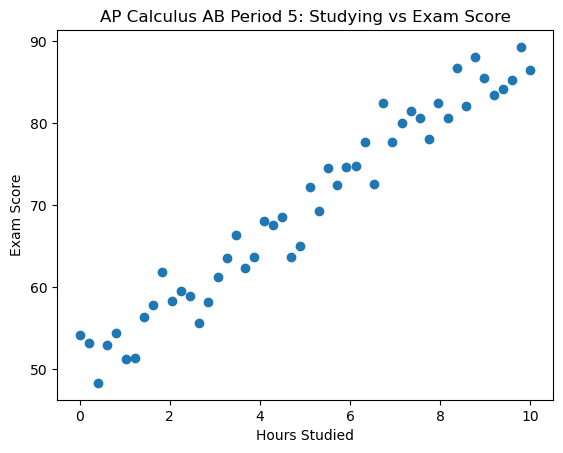

In [217]:
# Exam score with moderate noise
scores_new = 4 * hours + 50 + np.random.normal(0, 3, size=len(hours))

plt.figure()
plt.scatter(hours, scores_new)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 5: Studying vs Exam Score")
plt.show()

Now, we overlay each of our models to see how they visually compare to this new data:

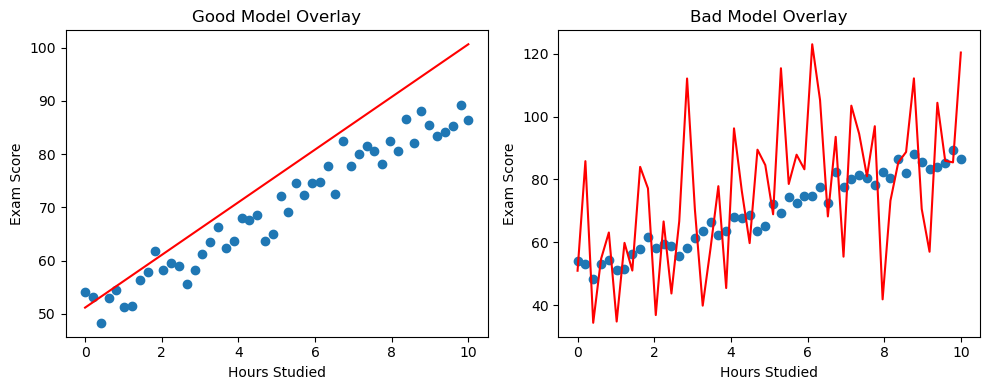

In [220]:
# side by side comparison of models 

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(hours, scores_new)
plt.plot(hours, y_fit_good, color = 'red')
plt.title("Good Model Overlay")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.subplot(1, 2, 2)
plt.scatter(hours, scores_new)
plt.plot(hours, y_fit_bad, color = 'red')
plt.title("Bad Model Overlay")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

It seems like our good model is a much closer guess (albeit not a great one). Let's quantify that using RMSE:

In [225]:
# RMSE for new data 

rmse_good_new = root_mean_squared_error(scores_new, y_fit_good)
rmse_bad_new = root_mean_squared_error(scores_new, y_fit_bad)

print(f'RMSE for Good Model on New Data: {round(rmse_good_new, 2)}')
print(f'RMSE for Bad Model on New Data: {round(rmse_bad_new, 2)}')

RMSE for Good Model on New Data: 7.38
RMSE for Bad Model on New Data: 20.9


As we can see, our good model has significantly better performance!

Let's compare that to its performance on its own data:

In [237]:
print(f'RMSE for Good Model Difference: {round(rmse_good_new - rmse_good, 2)}')
print(f'RMSE for Bad Model Difference: {round(rmse_bad_new - rmse_bad, 2)}')

RMSE for Good Model Difference: 2.51
RMSE for Bad Model Difference: 20.9


Since our RMSE performance on the new data was far worse for our bad model, this is a case of **overfitting**, or our model having poor performance on new data in comparison to the performance on its own data. Our good model had a much smaller difference, but still had some overfitting. 

Before moving on to overfitting, let's recap what we just saw: 

- Our model generated on bad data had great performance on its own bad data, but was terrible on new data. 

- Our model generated on good data had fine performance on its own good data, and had similar performance on new data. 

This illustrates the importance of having good data! It allows us to predict models that perform well on unseen data, which means we have generalizability. But why specifically does bad data cause this problem? And how could we even overcome this problem if all we have is bad data? 

## Overfitting

### What Is It? What Causes It? 

Overfitting occurs when the model's performance on its training data (think the good data for the good model, or the bad data for the bad model), is significantly better than the model's performance on its test data (think the period 5 data for both models). 

Overfitting happens when our model doesn't actually capture the underlying relationship, but rather the noise in the training data. So, when test data is used that doesn't have that same noise, the model has terrible performance! 

We already saw what a model that capture noise looks like as opposed to underlying trends - our side-by-side analysis! 

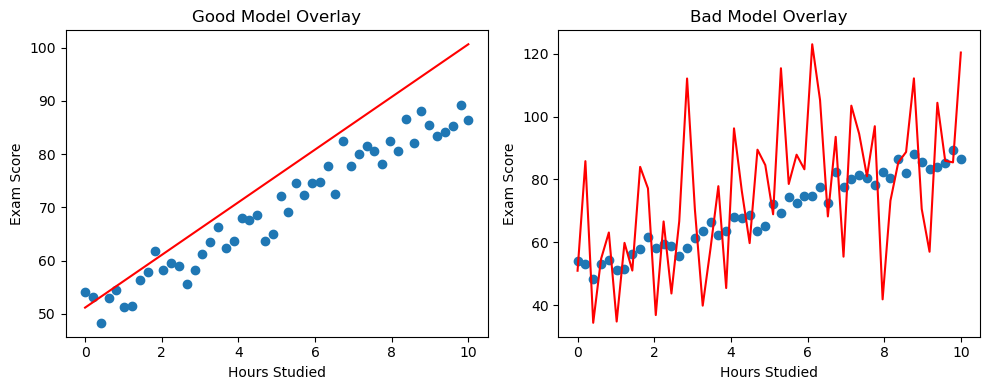

In [250]:
# copying over side by side comparison

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(hours, scores_new)
plt.plot(hours, y_fit_good, color = 'red')
plt.title("Good Model Overlay")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.subplot(1, 2, 2)
plt.scatter(hours, scores_new)
plt.plot(hours, y_fit_bad, color = 'red')
plt.title("Bad Model Overlay")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

Our bad model fit perfectly to the noisy bad data, but when the new data wasn't noisy, it struggled to get good performance.

This typically happens when we choose to pick a model with higher complexity, or more parameters. More parameters in the model polynomial allow us to model more nonlinearities, which is helpful in many cases (like where the true relationship is nonlinear), but if its capturing noise and not true nonlinearities, we are going to run into the above problem. 

Naturally, this makes us think that we should be using less parameters, or lower complexity. But, as we see with the line, using lower complexity means we can't capture nonlinearities if they are real parts of the relationship we are trying to measure. So, how do we balance this? 

### The Overfitting Problem: Bias-Variance Tradeoff

![](./ref_imgs/bias_variance_tradeoff.png)

Let's walk through what this chart is telling us. As model complexity goes up, our bias goes down, but our variance rises. Without getting too deep into math jargon, bias is how inaccurate our estimate is compared to the true value, and variance is how well our model would fit to other data. 

So, higher model complexity means that our estimates of true values become more accurate, but our model doesn't generalize well - this is overfitting! 

Lower model complexity, meanwhile, means that our bias is high, so our estimates are not as accurate, but our model generalizes better with lower variance. 

The "optimal" complexity that minimizes total error is somewhere in the middle, as shown by the chart. But how do we go about finding this optimal error? How can we limit our number of parameters without just random guesses? 

We will cover all of this in our next notebook! 